In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
from stable_baselines3 import PPO, DQN
from gymnasium.wrappers import RecordVideo
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import VecVideoRecorder
import os 
import do_mpc
from casadi import vertcat
from scipy.linalg import solve_discrete_are
import sys
sys.path.insert(0, os.path.abspath(os.path.join('..')))
from mpc.Cartpole_Control_Utils import *
import time

c:\Users\igrahek\AppData\Local\anaconda3\envs\shitty_bird_env\lib\site-packages\do_mpc\sysid\__init__.py:15: UserWarning: The ONNX feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The ONNX feature is not available. Please install the full version of do-mpc to access this feature.')
c:\Users\igrahek\AppData\Local\anaconda3\envs\shitty_bird_env\lib\site-packages\do_mpc\opcua\__init__.py:14: UserWarning: The opcua feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The opcua feature is not available. Please install the full version of do-mpc to access this feature.')


## Train and evaluate the models

In [2]:
# Create 'Results' folder if it doesn't exist
models_folder = "../results/Trained_Models/"
results_folder = "../results/PerformanceResults/"
videos_folder = "../results/Videos/"

# Make sure the folders exist
for folder in [models_folder, results_folder, videos_folder]:
    if not os.path.exists(folder):
        os.makedirs(folder)

# Lists for timing results
results_records = []

#------------------------------------------------------------------------------------------------------------------------------------------------
# Train/evaluate the MPC model
#------------------------------------------------------------------------------------------------------------------------------------------------
start_time = time.time()
mpc_results = evaluate_mpc_controllers(
        horizons=[10,20],
        recompute_intervals=[4, 7],
        length_ratios=[1,2],
        wind_mus=[0.0, 0.1], 
        wind_sigmas=[0.0, 0.1],
        results_folder="../results/PerformanceResults/",
        episode_length=500,
        num_episodes=2,
        linear=False,
        init_angles=[0.0, 0.1]
    )



## Pole length error

Found data for horizons: [10, 20] steps = ['0.2s', '0.4s']
Found data for recompute intervals: [4, 7] steps = ['0.08s', '0.14s']
Plotting ratios: [1.0, 2.0]

Plot saved to: ../results/PerformanceResults/mpc_4d_performance_heatmaps_wmu0.0_wsig0.0_iang0.00.png


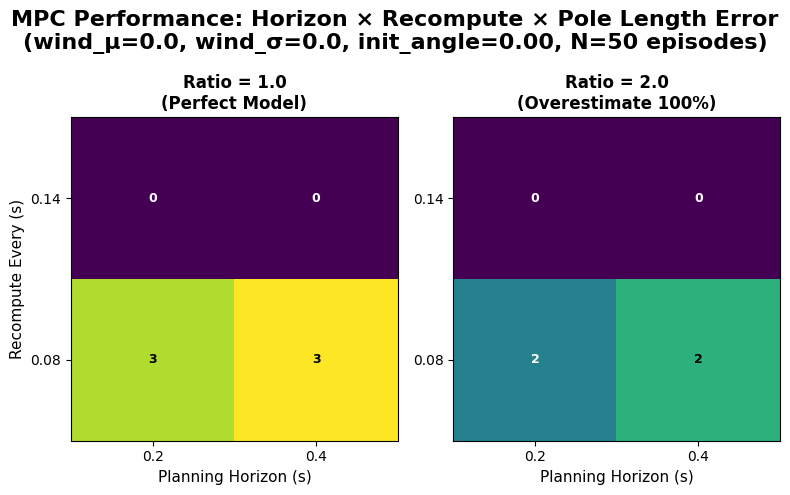

In [4]:
plot_4d_performance_heatmaps(results_folder="../results/PerformanceResults/", 
                                length_ratios=[1.0, 1.5, 2.0, 2.5, 3.0,],
                                wind_mu=0.0,
                                wind_sigma=0.0,
                                num_episodes=50)

## Wind error

Found data for horizons: [10, 20] steps = ['0.2s', '0.4s']
Found data for recompute intervals: [4, 7] steps = ['0.08s', '0.14s']
Plotting wind means: [0.0, 0.1]

Plot saved to: ../results/PerformanceResults/mpc_wind_mu_heatmaps_r1.0_s0.0_iang0.00.png


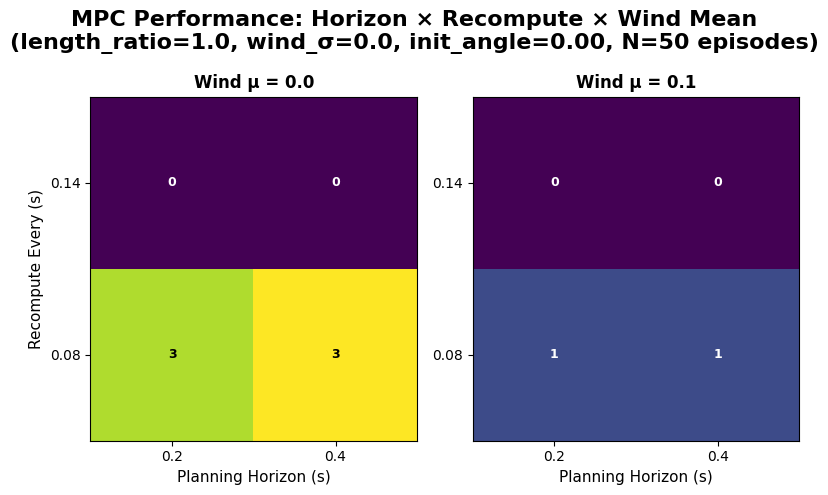

In [ ]:
plot_wind_mu_heatmaps(
    # results_folder="../results/PerformanceResults/",
    # wind_mus=[0.0, 0.1, 0.15, 0.2],
    # num_episodes=50,
    # length_ratio=1.0,
    # wind_sigma=0.0
)

## Initialization angle

Found data for horizons: [10, 20]
Found data for recompute intervals: [4, 7]
Plotting initial angles: [0.0, 0.1]

Plot saved to: ../results/PerformanceResults/mpc_init_angle_heatmaps_r1.0_m0.0_s0.0.png


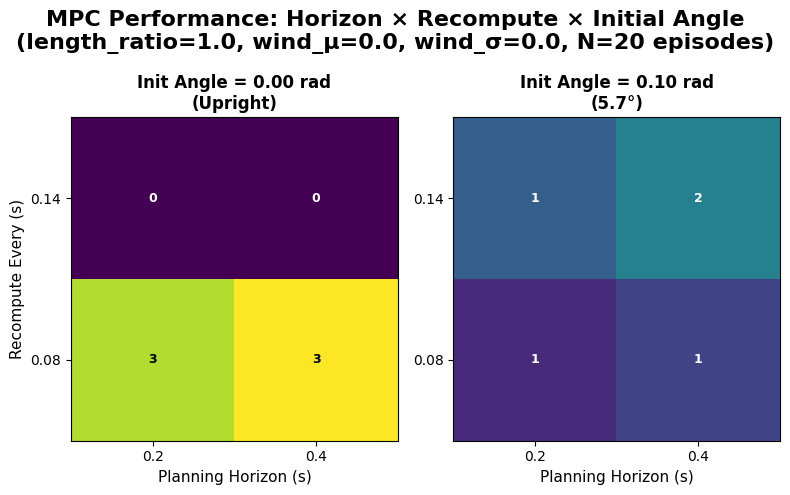

In [8]:
# Create heatmaps for different initial angles
plot_init_angle_heatmaps(
    # init_angles=[0.0, 0.1],
    # length_ratio=1.0,
    # wind_mu=0.0,
    # wind_sigma=0.0
)